In [1]:
import sys, platform
print(sys.executable)
print(platform.python_version())


C:\Users\user\anaconda3\envs\ai-biomed-py311\python.exe
3.11.15


In [1]:
import csv

with open("clinic_day.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["PatientID", "Glucose", "HeartRate", "OxygenSat"])
    writer.writerow(["P001", "95", "72", "98"])
    writer.writerow(["P002", "145", "90", "94"])
    writer.writerow(["P003", "130", "85", "96"])
    writer.writerow(["P004", "160", "100", "92"])


In [2]:
with open("clinic_day.csv") as f:
    print(f.read())


PatientID,Glucose,HeartRate,OxygenSat
P001,95,72,98
P002,145,90,94
P003,130,85,96
P004,160,100,92



In [3]:
import pandas as pd

df = pd.read_csv("clinic_day.csv")
df


,PatientID,Glucose,HeartRate,OxygenSat
0,P001,95,72,98
1,P002,145,90,94
2,P003,130,85,96
3,P004,160,100,92


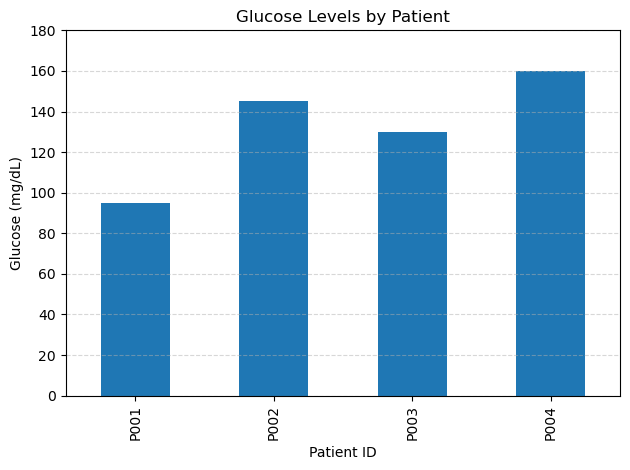

In [4]:
import matplotlib.pyplot as plt

df.plot(x="PatientID", y="Glucose", kind="bar", legend=False)
plt.title("Glucose Levels by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Glucose (mg/dL)")
plt.ylim(0, df["Glucose"].max() + 20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


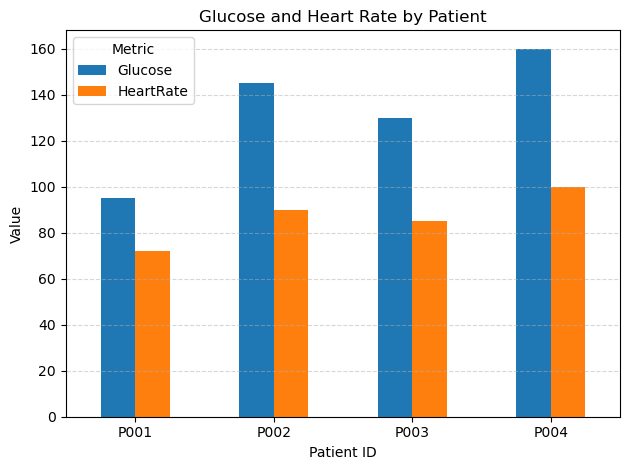

In [5]:
df_plot = df.set_index("PatientID")[["Glucose", "HeartRate"]]

ax = df_plot.plot(kind="bar")
ax.set_title("Glucose and Heart Rate by Patient")
ax.set_xlabel("Patient ID")
ax.set_ylabel("Value")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


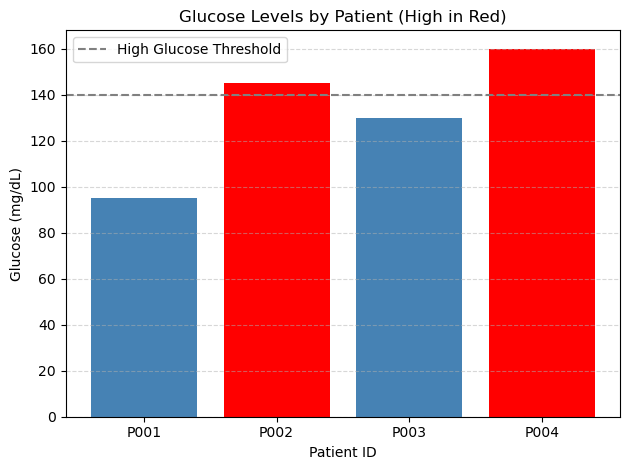

In [6]:
import numpy as np
import matplotlib.pyplot as plt

GLUCOSE_HIGH = 140

colors = np.where(df["Glucose"] > GLUCOSE_HIGH, "red", "steelblue")

plt.bar(df["PatientID"], df["Glucose"], color=colors)
plt.axhline(GLUCOSE_HIGH, color="gray", linestyle="--", label="High Glucose Threshold")
plt.title("Glucose Levels by Patient (High in Red)")
plt.xlabel("Patient ID")
plt.ylabel("Glucose (mg/dL)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


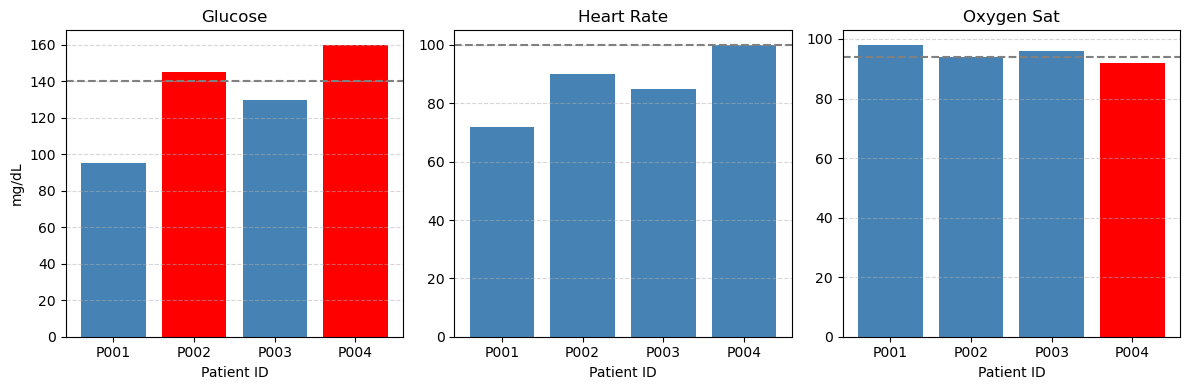

In [7]:
GLUCOSE_HIGH = 140
HR_HIGH = 100
O2_LOW = 94

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

# Glucose
axes[0].bar(df["PatientID"], df["Glucose"],
            color=np.where(df["Glucose"] > GLUCOSE_HIGH, "red", "steelblue"))
axes[0].axhline(GLUCOSE_HIGH, color="gray", linestyle="--")
axes[0].set_title("Glucose")
axes[0].set_ylabel("mg/dL")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Heart Rate
axes[1].bar(df["PatientID"], df["HeartRate"],
            color=np.where(df["HeartRate"] > HR_HIGH, "red", "steelblue"))
axes[1].axhline(HR_HIGH, color="gray", linestyle="--")
axes[1].set_title("Heart Rate")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# Oxygen Saturation
axes[2].bar(df["PatientID"], df["OxygenSat"],
            color=np.where(df["OxygenSat"] < O2_LOW, "red", "steelblue"))
axes[2].axhline(O2_LOW, color="gray", linestyle="--")
axes[2].set_title("Oxygen Sat")
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

for ax in axes:
    ax.set_xlabel("Patient ID")
    ax.set_xticks(df["PatientID"])

plt.tight_layout()
plt.show()


In [8]:
df_sorted = df.sort_values(by="Glucose", ascending=False)
df_sorted


,PatientID,Glucose,HeartRate,OxygenSat
3,P004,160,100,92
1,P002,145,90,94
2,P003,130,85,96
0,P001,95,72,98


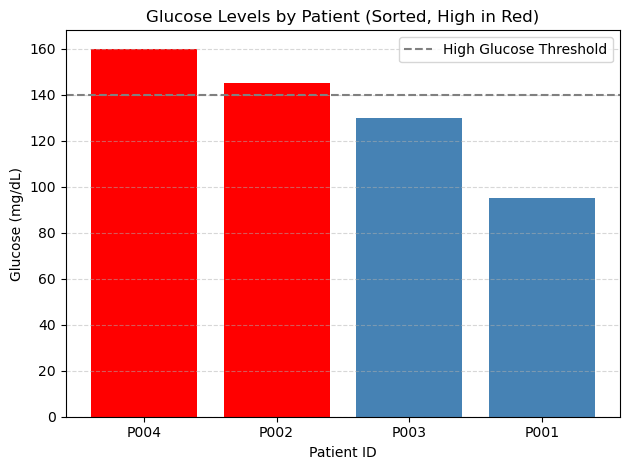

In [9]:
import numpy as np
import matplotlib.pyplot as plt

GLUCOSE_HIGH = 140

colors = np.where(df_sorted["Glucose"] > GLUCOSE_HIGH, "red", "steelblue")

plt.bar(df_sorted["PatientID"], df_sorted["Glucose"], color=colors)
plt.axhline(GLUCOSE_HIGH, color="gray", linestyle="--", label="High Glucose Threshold")
plt.title("Glucose Levels by Patient (Sorted, High in Red)")
plt.xlabel("Patient ID")
plt.ylabel("Glucose (mg/dL)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


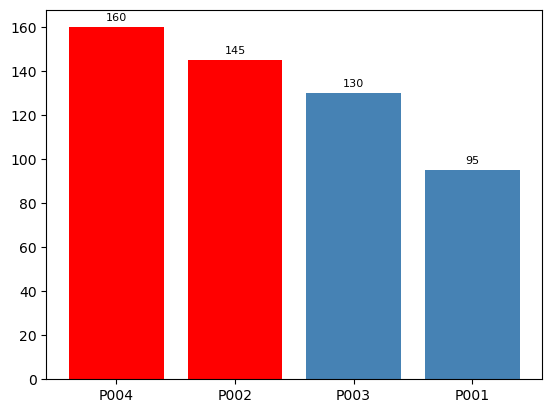

In [10]:
bars = plt.bar(df_sorted["PatientID"], df_sorted["Glucose"], color=colors)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{height}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),  # pixels above bar
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )


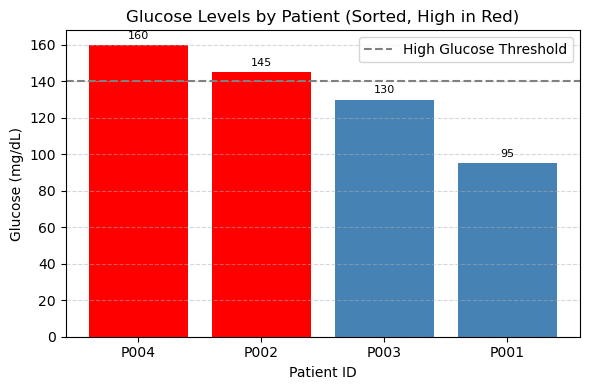

In [11]:
GLUCOSE_HIGH = 140

df_sorted = df.sort_values(by="Glucose", ascending=False)
colors = np.where(df_sorted["Glucose"] > GLUCOSE_HIGH, "red", "steelblue")

plt.figure(figsize=(6,4))
bars = plt.bar(df_sorted["PatientID"], df_sorted["Glucose"], color=colors)
plt.axhline(GLUCOSE_HIGH, color="gray", linestyle="--", label="High Glucose Threshold")
plt.title("Glucose Levels by Patient (Sorted, High in Red)")
plt.xlabel("Patient ID")
plt.ylabel("Glucose (mg/dL)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{height}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


In [12]:
def compute_risk(row):
    score = 0
    if row["Glucose"] > 140:
        score += 2
    if row["HeartRate"] > 100:
        score += 2
    if row["OxygenSat"] < 94:
        score += 2
    return score

df["RiskScore"] = df.apply(compute_risk, axis=1)
df


,PatientID,Glucose,HeartRate,OxygenSat,RiskScore
0,P001,95,72,98,0
1,P002,145,90,94,2
2,P003,130,85,96,0
3,P004,160,100,92,4


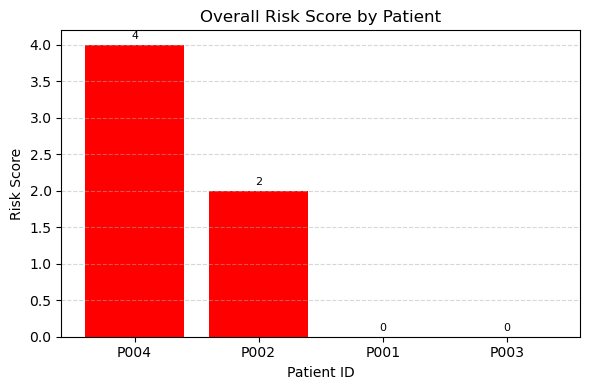

In [13]:
df_risk = df.sort_values(by="RiskScore", ascending=False)

import matplotlib.pyplot as plt

colors = ["red" if score >= 2 else "steelblue" for score in df_risk["RiskScore"]]

plt.figure(figsize=(6, 4))
bars = plt.bar(df_risk["PatientID"], df_risk["RiskScore"], color=colors)
plt.title("Overall Risk Score by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Risk Score")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


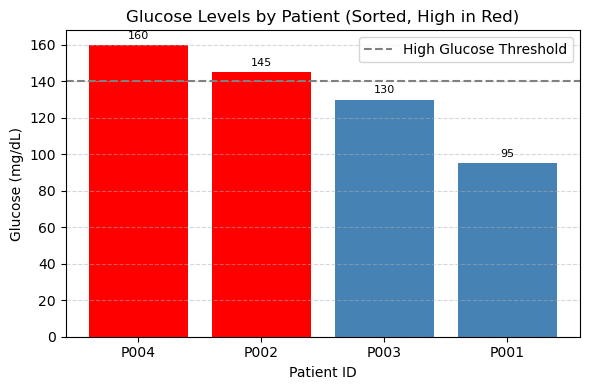

In [14]:
import numpy as np
import matplotlib.pyplot as plt

GLUCOSE_HIGH = 140

df_sorted = df.sort_values(by="Glucose", ascending=False)
colors = np.where(df_sorted["Glucose"] > GLUCOSE_HIGH, "red", "steelblue")

plt.figure(figsize=(6, 4))
bars = plt.bar(df_sorted["PatientID"], df_sorted["Glucose"], color=colors)
plt.axhline(GLUCOSE_HIGH, color="gray", linestyle="--", label="High Glucose Threshold")
plt.title("Glucose Levels by Patient (Sorted, High in Red)")
plt.xlabel("Patient ID")
plt.ylabel("Glucose (mg/dL)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()

# NEW: save to file (PNG, 150 DPI)
plt.savefig("glucose_risk_dashboard.png", dpi=150)

plt.show()


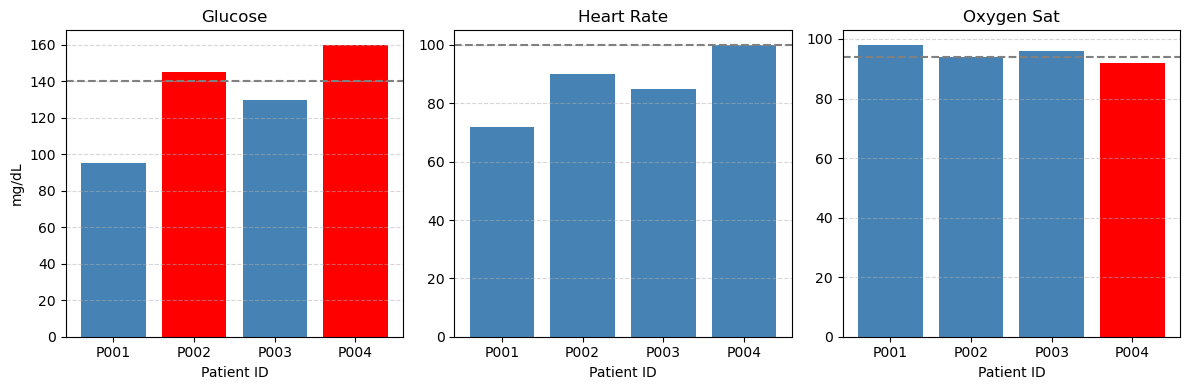

In [15]:
GLUCOSE_HIGH = 140
HR_HIGH = 100
O2_LOW = 94

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

# Glucose
axes[0].bar(df["PatientID"], df["Glucose"],
            color=np.where(df["Glucose"] > GLUCOSE_HIGH, "red", "steelblue"))
axes[0].axhline(GLUCOSE_HIGH, color="gray", linestyle="--")
axes[0].set_title("Glucose")
axes[0].set_ylabel("mg/dL")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Heart Rate
axes[1].bar(df["PatientID"], df["HeartRate"],
            color=np.where(df["HeartRate"] > HR_HIGH, "red", "steelblue"))
axes[1].axhline(HR_HIGH, color="gray", linestyle="--")
axes[1].set_title("Heart Rate")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# Oxygen Saturation
axes[2].bar(df["PatientID"], df["OxygenSat"],
            color=np.where(df["OxygenSat"] < O2_LOW, "red", "steelblue"))
axes[2].axhline(O2_LOW, color="gray", linestyle="--")
axes[2].set_title("Oxygen Sat")
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

for ax in axes:
    ax.set_xlabel("Patient ID")
    ax.set_xticks(df["PatientID"])

plt.tight_layout()

# NEW: save this figure
fig.savefig("clinic_vitals_dashboard.png", dpi=150)

plt.show()


In [16]:
import os

print(os.listdir())


['.ipynb_checkpoints', 'clinic_day.csv', 'clinic_vitals_dashboard.png', 'glucose_risk_dashboard.png', 'patient_v1.csv', 'patient_v2.csv', 'test.ipynb', 'Untitled.ipynb', 'week1_day2_functions.ipynb', 'week1_day2_functions_assignment.ipynb', 'week1_day3_data.ipynb']


In [17]:
## Week 1 Day 3 — CSV Loading, Pandas, and Clinical Visualisation

**Dataset:** Custom `clinic_day.csv` (4 patients, 4 vitals columns)  
**Key skills practiced:** `csv.reader` vs `DictReader`, pandas `DataFrame`, matplotlib bar charts, clinical thresholds, risk scoring, export to PNG  
**Key finding:** P004 is highest risk (RiskScore = 4) due to elevated Glucose and low OxygenSat


SyntaxError: invalid syntax (3976214588.py, line 3)

## Week 1 Day 3 — CSV Loading, Pandas, and Clinical Visualisation

**Dataset:** Custom `clinic_day.csv` (4 patients, 4 vitals columns)  
**Key skills practiced:** `csv.reader` vs `DictReader`, pandas `DataFrame`, matplotlib bar charts, clinical thresholds, risk scoring, export to PNG  
**Key finding:** P004 is highest risk (RiskScore = 4) due to elevated Glucose and low OxygenSat


## Reflection — Clinical Limitations of Simple Risk Scoring

A flat +2 per abnormal vital ignores that different conditions carry 
different clinical weight. Slight tachycardia in an anxious patient 
is not equivalent to critically low SpO2 in someone with pneumonia.

Additive scores also miss interactions — mildly high HR plus borderline 
low SpO2 may be far more dangerous together than either alone, but the 
model just sums them as 4 points.

**Key failure modes:**
- Over-alerting → alarm fatigue → clinicians ignore real alerts
- Under-alerting → dangerous patterns missed
- Distribution shift → thresholds tuned on one population fail on another
- False precision → a number that looks objective but is a rough heuristic

**Concepts to revisit:** NEWS2 scoring, model governance (Week 6), 
dataset shift (Week 3+)

## Reflection — Clinical Limitations of Simple Risk Scoring

A flat +2 per abnormal vital ignores that different conditions carry 
different clinical weight. Slight tachycardia in an anxious patient 
is not equivalent to critically low SpO2 in someone with pneumonia.

Additive scores also miss interactions — mildly high HR plus borderline 
low SpO2 may be far more dangerous together than either alone, but the 
model just sums them as 4 points.

**Key failure modes:**
- Over-alerting → alarm fatigue → clinicians ignore real alerts
- Under-alerting → dangerous patterns missed
- Distribution shift → thresholds tuned on one population fail on another
- False precision → a number that looks objective but is a rough heuristic

**Concepts to revisit:** NEWS2 scoring, model governance (Week 6), 
dataset shift (Week 3+)